# 데이터 탐색 - 아프리카 질병 감염률 예측

## 1. 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. 데이터 로드 및 변수 정의

In [2]:
# 데이터 로드
df = pd.read_csv('../data/processed/cleaned_disease_dataset_2015landuse.csv')

# 컬럼 분류
key_cols = ['year', 'country', 'admin']
target_col = 'infection_rate'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Buffa', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Total samples: {len(df):,}")
print(f"Features: {len(feature_cols)} ({', '.join(feature_cols[:3])}...)")
print(f"\nData preview:")
df.head()

Total samples: 473
Features: 12 (max_temperature, min_temperature, avg_temperature...)

Data preview:


,year,country,admin,infection_rate,max_temperature,min_temperature,avg_temperature,Buffa,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,missing_ratio
0,2010,Burkina Faso,Boucle Du Mouhoun,0.585652,307.42114,297.76172,302.50760,0.0,25.000049,164.065700,0.0,34.153420,0.693863,21.774243,9.682960,0.076206,0.0
1,2010,Burkina Faso,Cascades,0.979432,304.47192,297.88160,300.27893,0.0,38.008688,96.864817,0.0,12.506484,0.008877,12.373391,3.865450,0.074387,0.0
2,2010,Burkina Faso,Centre,1.955671,307.73170,299.50660,302.80447,0.0,17.566445,303.908919,0.0,58.134766,0.019041,40.947445,6.821150,0.407856,0.0
3,2010,Burkina Faso,Centre-est,1.037736,307.41138,298.78003,302.61942,0.0,29.597071,203.094681,0.0,69.010943,0.027864,45.871831,18.292361,0.143950,0.0
4,2010,Burkina Faso,Centre-nord,0.379147,308.31274,297.82104,303.14368,0.0,28.843678,138.295650,0.0,65.134086,0.079677,48.346972,4.834737,0.120649,0.0


## 3. 기술통계량

In [3]:
# 전체 기술통계량
print("=== 기술통계량 ===")
df.describe().T

=== 기술통계량 ===


,count,mean,std,min,25%,50%,75%,max
year,473.0,2010.951374,4.770114,2001.000000,2007.000000,2012.000000,2015.000000,2019.000000
infection_rate,473.0,5.420915,6.599666,0.000000,1.075992,2.145923,7.500000,27.073403
max_temperature,473.0,300.919423,4.942571,287.423830,298.385000,300.922360,304.870120,312.692870
min_temperature,473.0,293.797237,5.574112,274.071530,292.032700,295.414550,297.678470,302.017100
avg_temperature,473.0,297.503255,4.620090,282.297270,295.419650,298.334930,300.826480,304.935330
Buffa,473.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Cattl,473.0,21.177643,28.849973,0.000000,3.476136,13.409063,27.484364,257.216200
Chick,473.0,203.419074,799.722868,0.000000,25.432071,61.851499,155.058302,10834.898438
Ducks,473.0,1.088852,5.561289,0.000000,0.000000,0.000000,0.165793,69.299351
Goats,473.0,25.217922,33.261851,0.000000,5.880530,14.949026,31.419340,264.313783


## 4. Target 변수 분포 분석

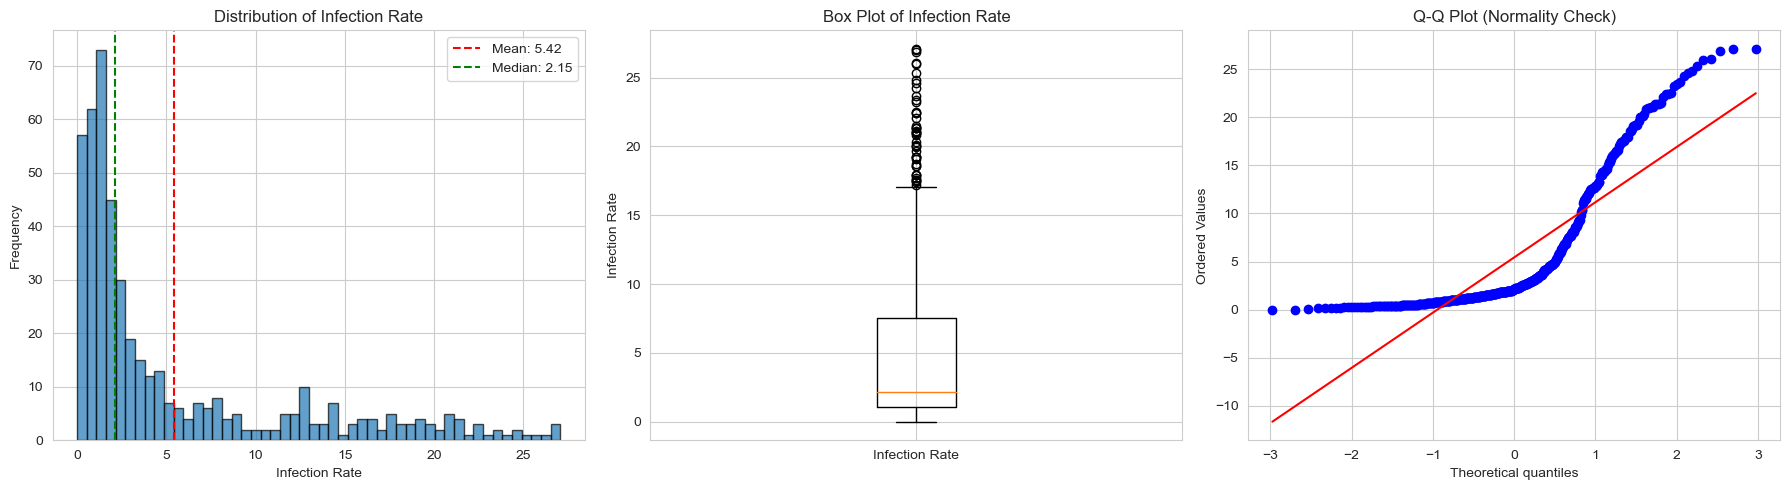


Shapiro-Wilk 정규성 검정: p-value = 0.0000
→ 정규분포를 따르지 않습니다 (p < 0.05)


In [5]:
# Target 변수 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df[target_col], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df[target_col].mean(), color='red', linestyle='--', label=f'Mean: {df[target_col].mean():.2f}')
axes[0].axvline(df[target_col].median(), color='green', linestyle='--', label=f'Median: {df[target_col].median():.2f}')
axes[0].set_xlabel('Infection Rate')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Infection Rate')
axes[0].legend()

# Box plot
axes[1].boxplot(df[target_col])
axes[1].set_ylabel('Infection Rate')
axes[1].set_title('Box Plot of Infection Rate')
axes[1].set_xticklabels(['Infection Rate'])

# Q-Q plot (정규성 확인)
stats.probplot(df[target_col], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

# 정규성 검정
stat, p_value = shapiro(df[target_col])
print(f"\nShapiro-Wilk 정규성 검정: p-value = {p_value:.4f}")
if p_value > 0.05:
    print("→ 정규분포를 따릅니다 (p > 0.05)")
else:
    print("→ 정규분포를 따르지 않습니다 (p < 0.05)")

## 5. 시계열 분석

In [6]:
# 연도별 분포
print("=== 연도별 데이터 분포 ===")
print(df['year'].value_counts().sort_index())

=== 연도별 데이터 분포 ===
year
2001     9
2003    31
2004    23
2005    29
2006    21
2007    11
2008    14
2009    30
2010    41
2011    21
2012    31
2013    48
2014    35
2015    41
2016    36
2017    13
2018    24
2019    15
Name: count, dtype: int64


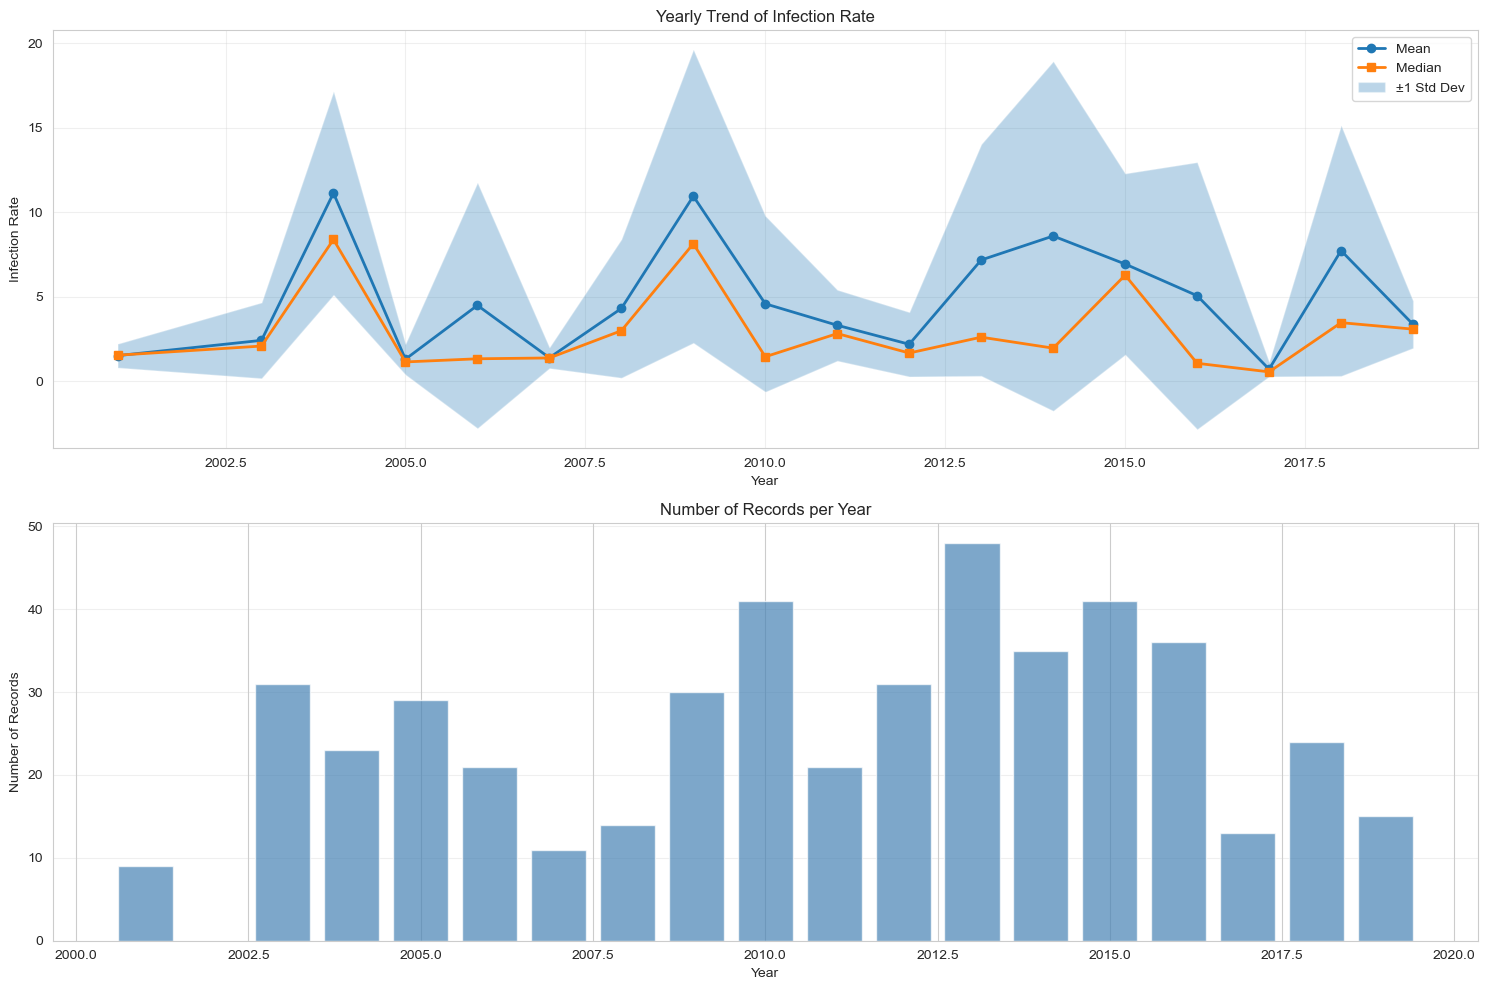

In [7]:
# 연도별 감염률 추이
yearly_stats = df.groupby('year')[target_col].agg(['mean', 'median', 'std', 'count']).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 평균 및 중앙값 추이
axes[0].plot(yearly_stats['year'], yearly_stats['mean'], marker='o', label='Mean', linewidth=2)
axes[0].plot(yearly_stats['year'], yearly_stats['median'], marker='s', label='Median', linewidth=2)
axes[0].fill_between(yearly_stats['year'], 
                      yearly_stats['mean'] - yearly_stats['std'],
                      yearly_stats['mean'] + yearly_stats['std'],
                      alpha=0.3, label='±1 Std Dev')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Infection Rate')
axes[0].set_title('Yearly Trend of Infection Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 샘플 수 추이
axes[1].bar(yearly_stats['year'], yearly_stats['count'], alpha=0.7, color='steelblue')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Records')
axes[1].set_title('Number of Records per Year')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. 지역별 분석

In [8]:
# 국가별 통계
print("=== 국가별 정보 ===")
print(f"총 국가 수: {df['country'].nunique()}")
print(f"국가 목록: {sorted(df['country'].unique())}")
print(f"\n국가별 데이터 수:")
print(df['country'].value_counts())

=== 국가별 정보 ===
총 국가 수: 28
국가 목록: ['Angola', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Congo', 'Democratic Republic of the Congo', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Kenya', 'Lesotho', 'Malawi', 'Mali', 'Mozambique', 'Namibia', 'Niger', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Sierra Leone', 'South Africa', 'Swaziland', 'Togo', 'Zambia', 'Zimbabwe']

국가별 데이터 수:
country
Senegal                             36
Ethiopia                            33
Lesotho                             30
Cameroon                            27
Burkina Faso                        26
Mali                                24
Guinea                              24
Democratic Republic of the Congo    22
Ghana                               20
Zimbabwe                            20
Mozambique                          20
Zambia                              18
Angola                              18
Gabon                               18
Burundi                             17
Niger           

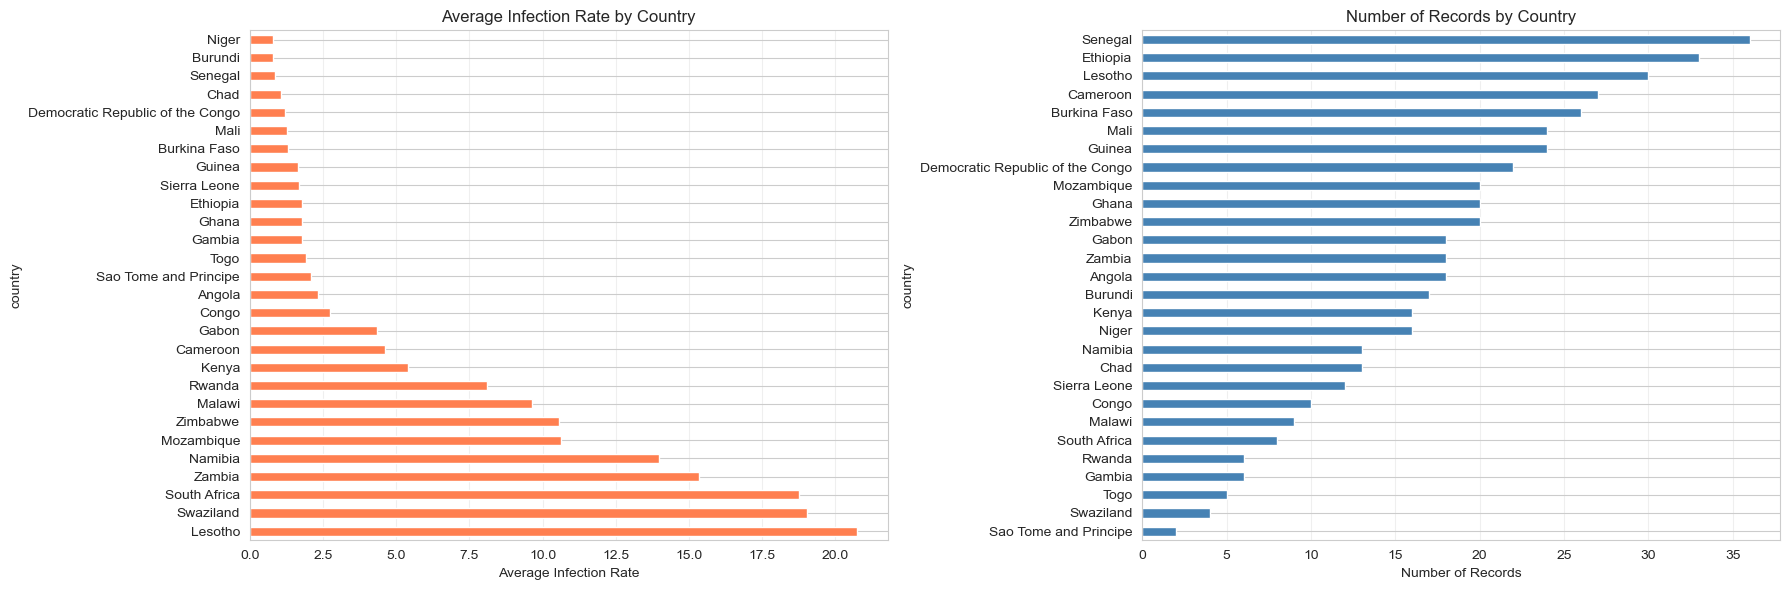

In [9]:
# 국가별 평균 감염률
country_stats = df.groupby('country')[target_col].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 국가별 평균 감염률
country_stats['mean'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_xlabel('Average Infection Rate')
axes[0].set_title('Average Infection Rate by Country')
axes[0].grid(True, alpha=0.3, axis='x')

# 국가별 데이터 수
country_stats['count'].sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Number of Records')
axes[1].set_title('Number of Records by Country')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 7. Feature 분포 분석

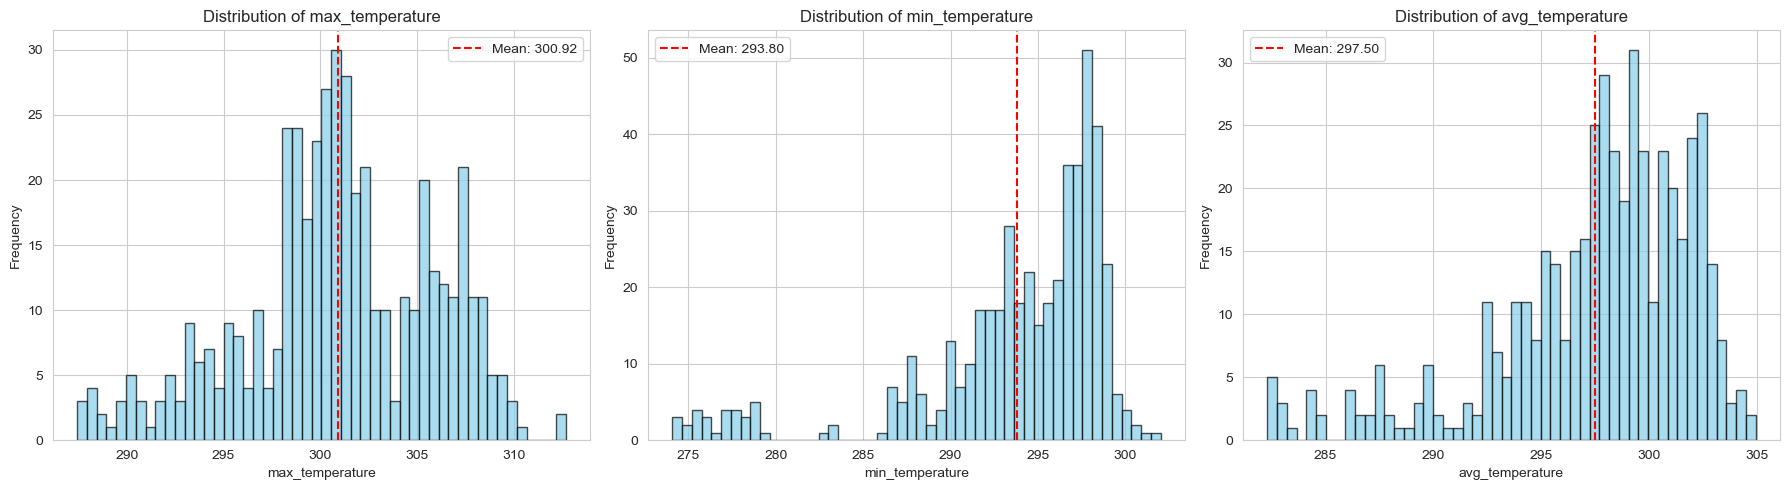

In [11]:
# 기후 변수 분포
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(climate_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

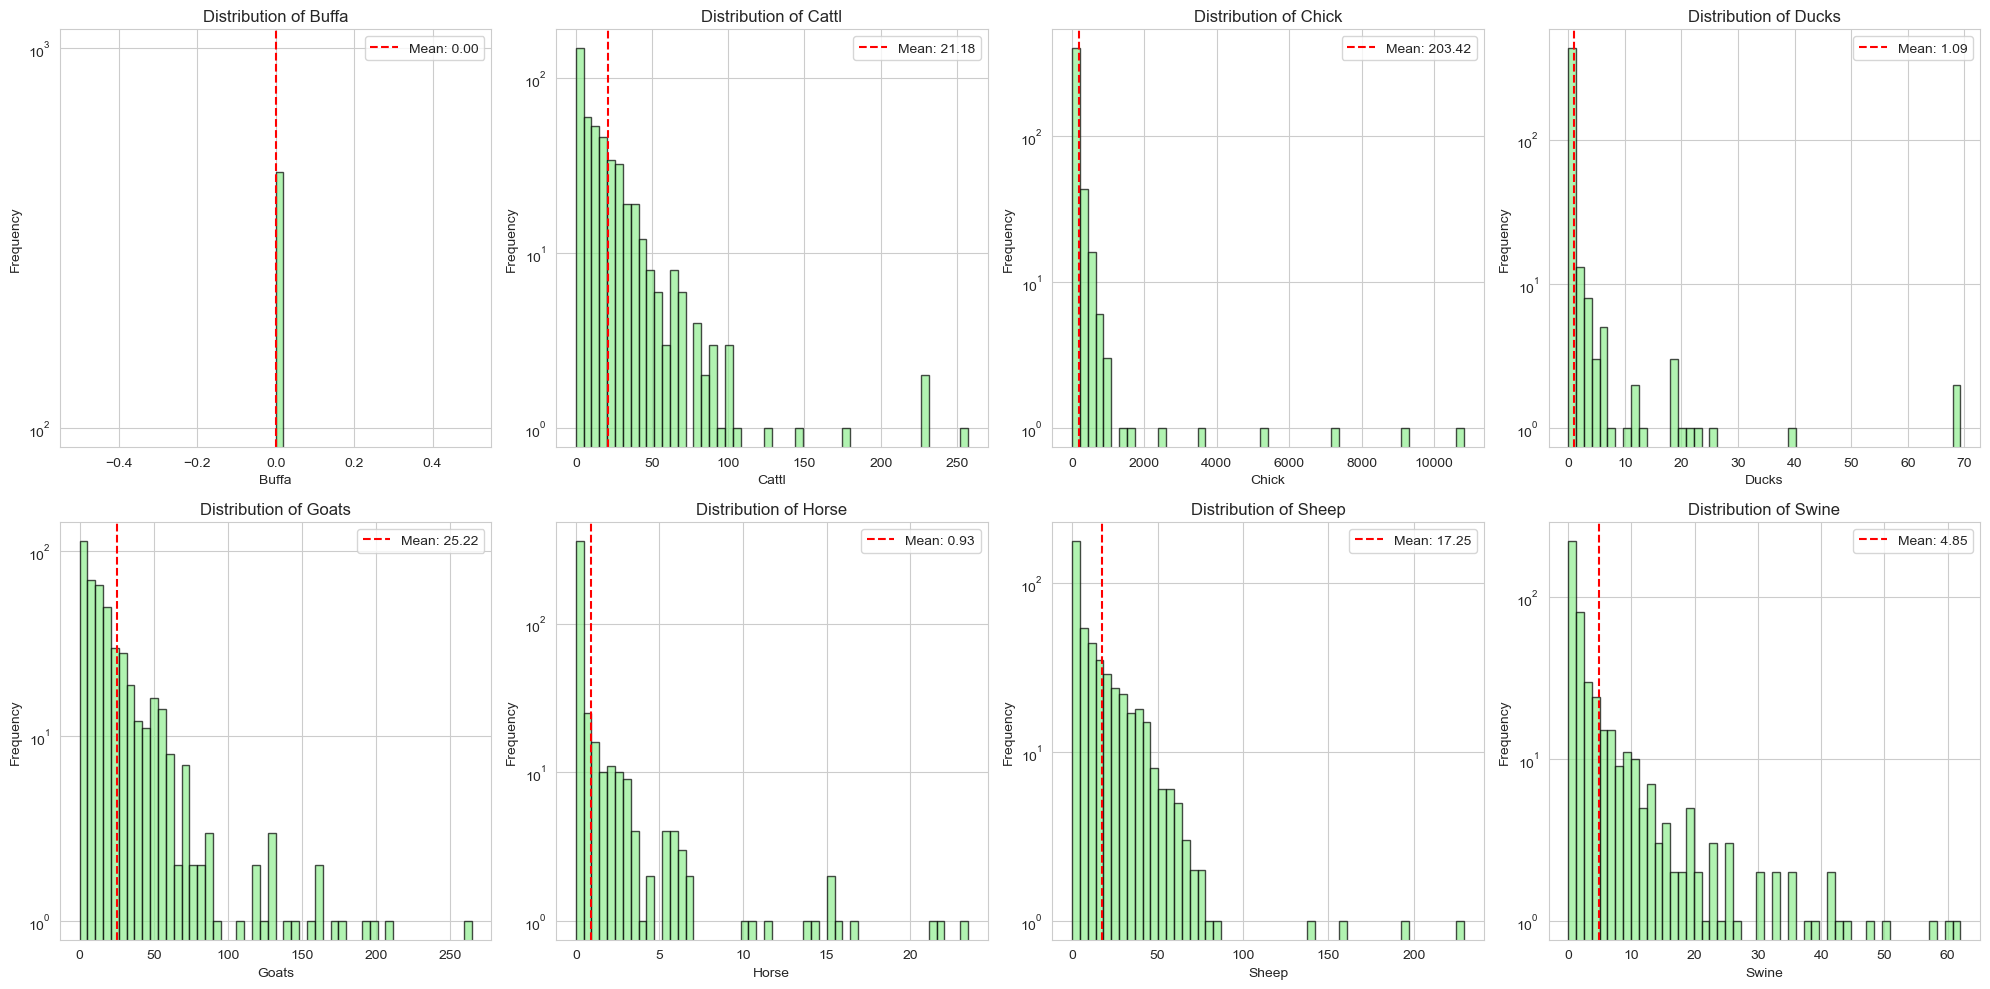

In [12]:
# 가축 변수 분포
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(livestock_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].legend()
    axes[idx].set_yscale('log')  # 로그 스케일로 표시

plt.tight_layout()
plt.show()

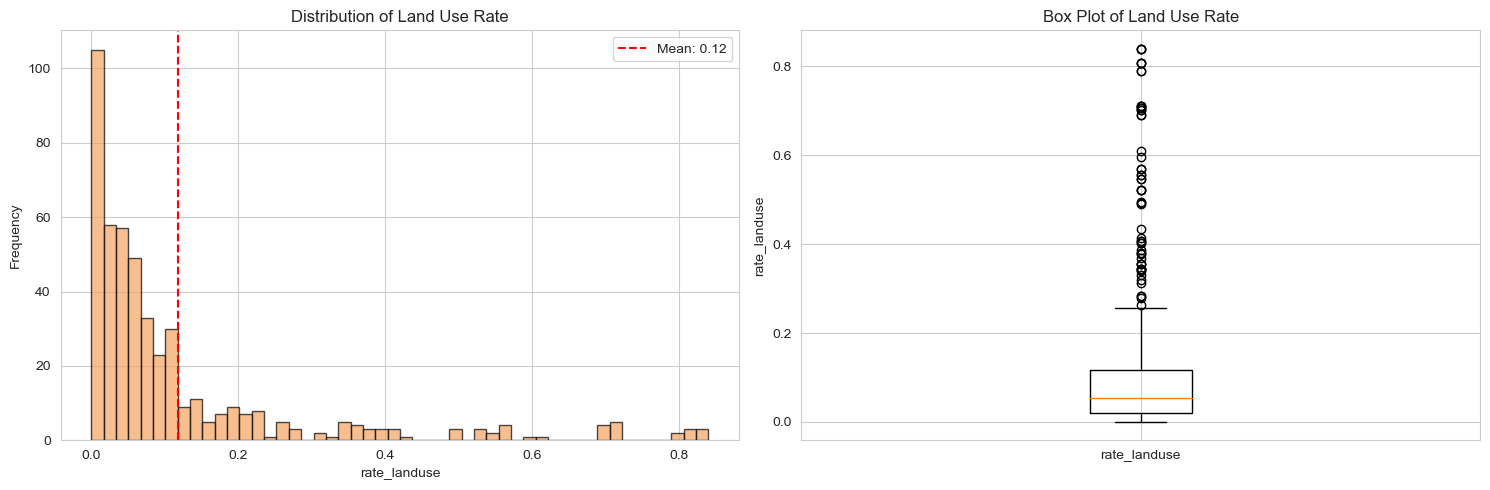

In [13]:
# 토지이용 변수 분포
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['rate_landuse'], bins=50, edgecolor='black', alpha=0.7, color='sandybrown')
axes[0].axvline(df['rate_landuse'].mean(), color='red', linestyle='--', label=f'Mean: {df["rate_landuse"].mean():.2f}')
axes[0].set_xlabel('rate_landuse')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Land Use Rate')
axes[0].legend()

axes[1].boxplot(df['rate_landuse'])
axes[1].set_ylabel('rate_landuse')
axes[1].set_title('Box Plot of Land Use Rate')
axes[1].set_xticklabels(['rate_landuse'])

plt.tight_layout()
plt.show()

## 8. 이상치 탐지

In [14]:
# IQR 방법으로 이상치 탐지
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("=== 이상치 탐지 (IQR 방법) ===")
outlier_summary = []

for col in feature_cols + [target_col]:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_ratio = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Column': col,
        'N_Outliers': n_outliers,
        'Outlier_Ratio(%)': f'{outlier_ratio:.2f}',
        'Lower_Bound': f'{lower:.2f}',
        'Upper_Bound': f'{upper:.2f}'
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

=== 이상치 탐지 (IQR 방법) ===


,Column,N_Outliers,Outlier_Ratio(%),Lower_Bound,Upper_Bound
0,max_temperature,8,1.69,288.66,314.60
1,min_temperature,33,6.98,283.56,306.15
2,avg_temperature,23,4.86,287.31,308.94
3,Buffa,0,0.00,0.00,0.00
4,Cattl,32,6.77,-32.54,63.50
5,Chick,39,8.25,-169.01,349.50
6,Ducks,72,15.22,-0.25,0.41
7,Goats,32,6.77,-32.43,69.73
8,Horse,83,17.55,-0.60,1.01
9,Sheep,14,2.96,-36.04,63.18


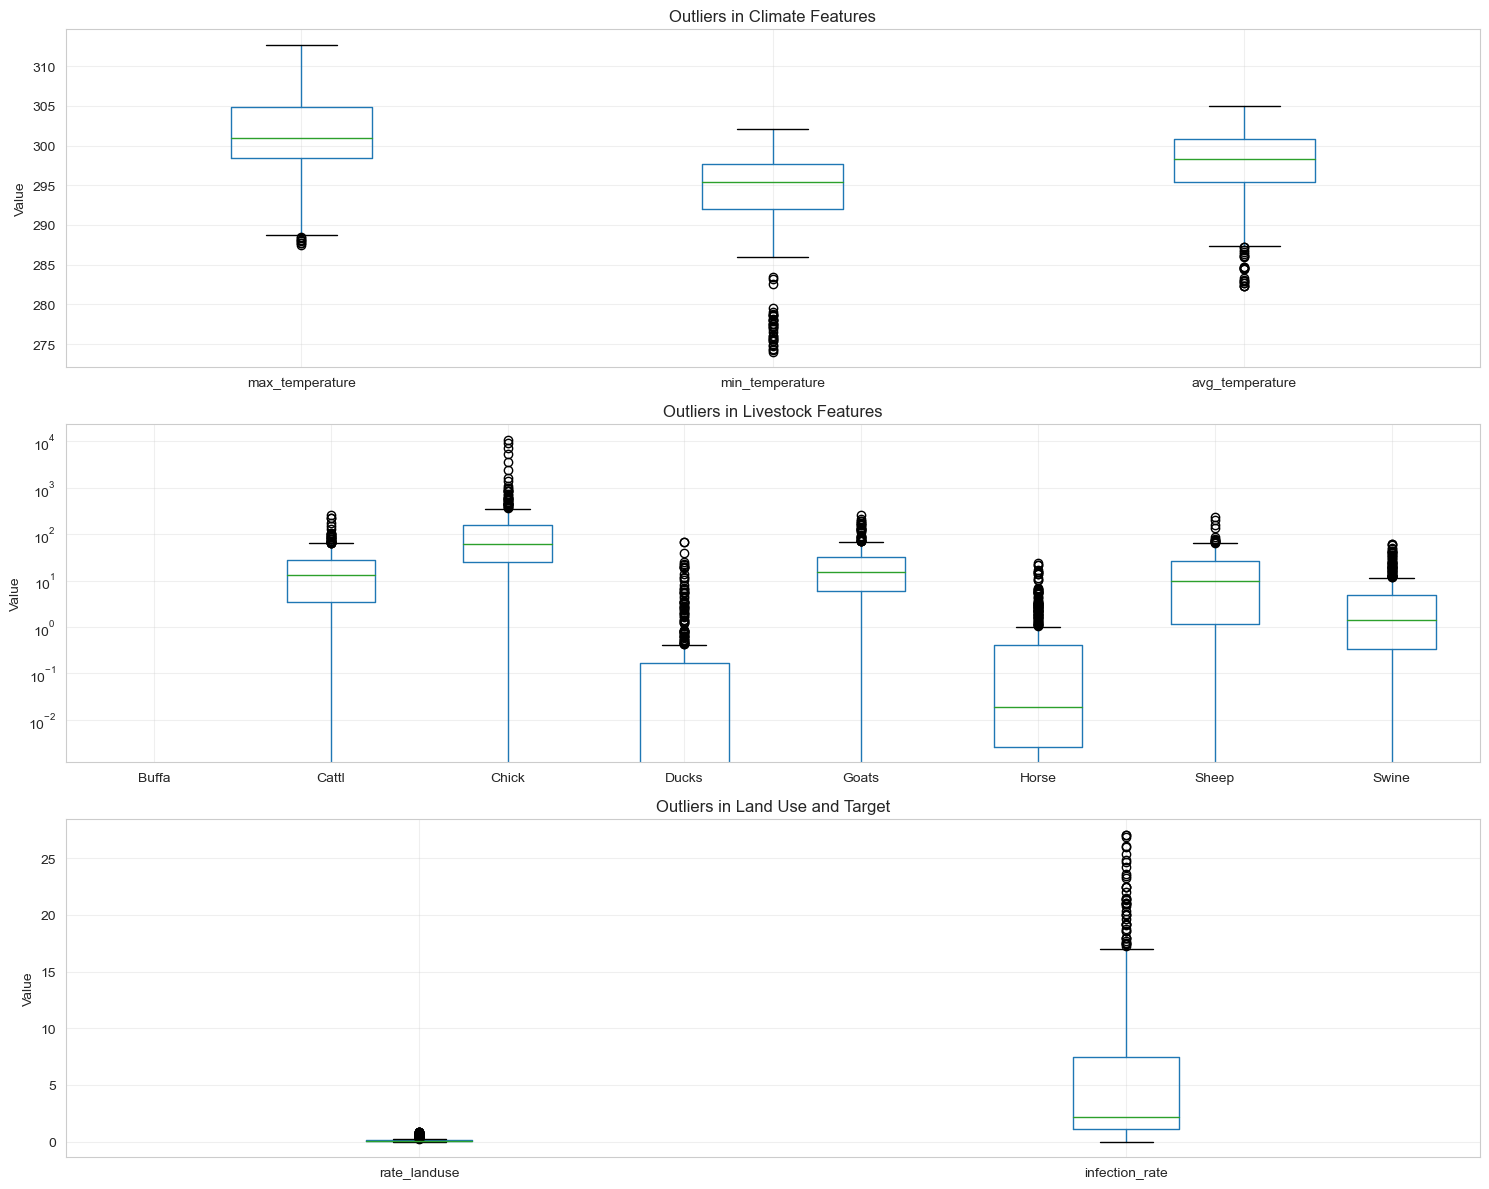

In [15]:
# Box plot으로 이상치 시각화
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Climate features
df[climate_cols].boxplot(ax=axes[0])
axes[0].set_title('Outliers in Climate Features')
axes[0].set_ylabel('Value')
axes[0].grid(True, alpha=0.3)

# Livestock features
df[livestock_cols].boxplot(ax=axes[1])
axes[1].set_title('Outliers in Livestock Features')
axes[1].set_ylabel('Value')
axes[1].set_yscale('log')  # 로그 스케일
axes[1].grid(True, alpha=0.3)

# Landuse and Target
df[landuse_cols + [target_col]].boxplot(ax=axes[2])
axes[2].set_title('Outliers in Land Use and Target')
axes[2].set_ylabel('Value')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 상관관계 분석

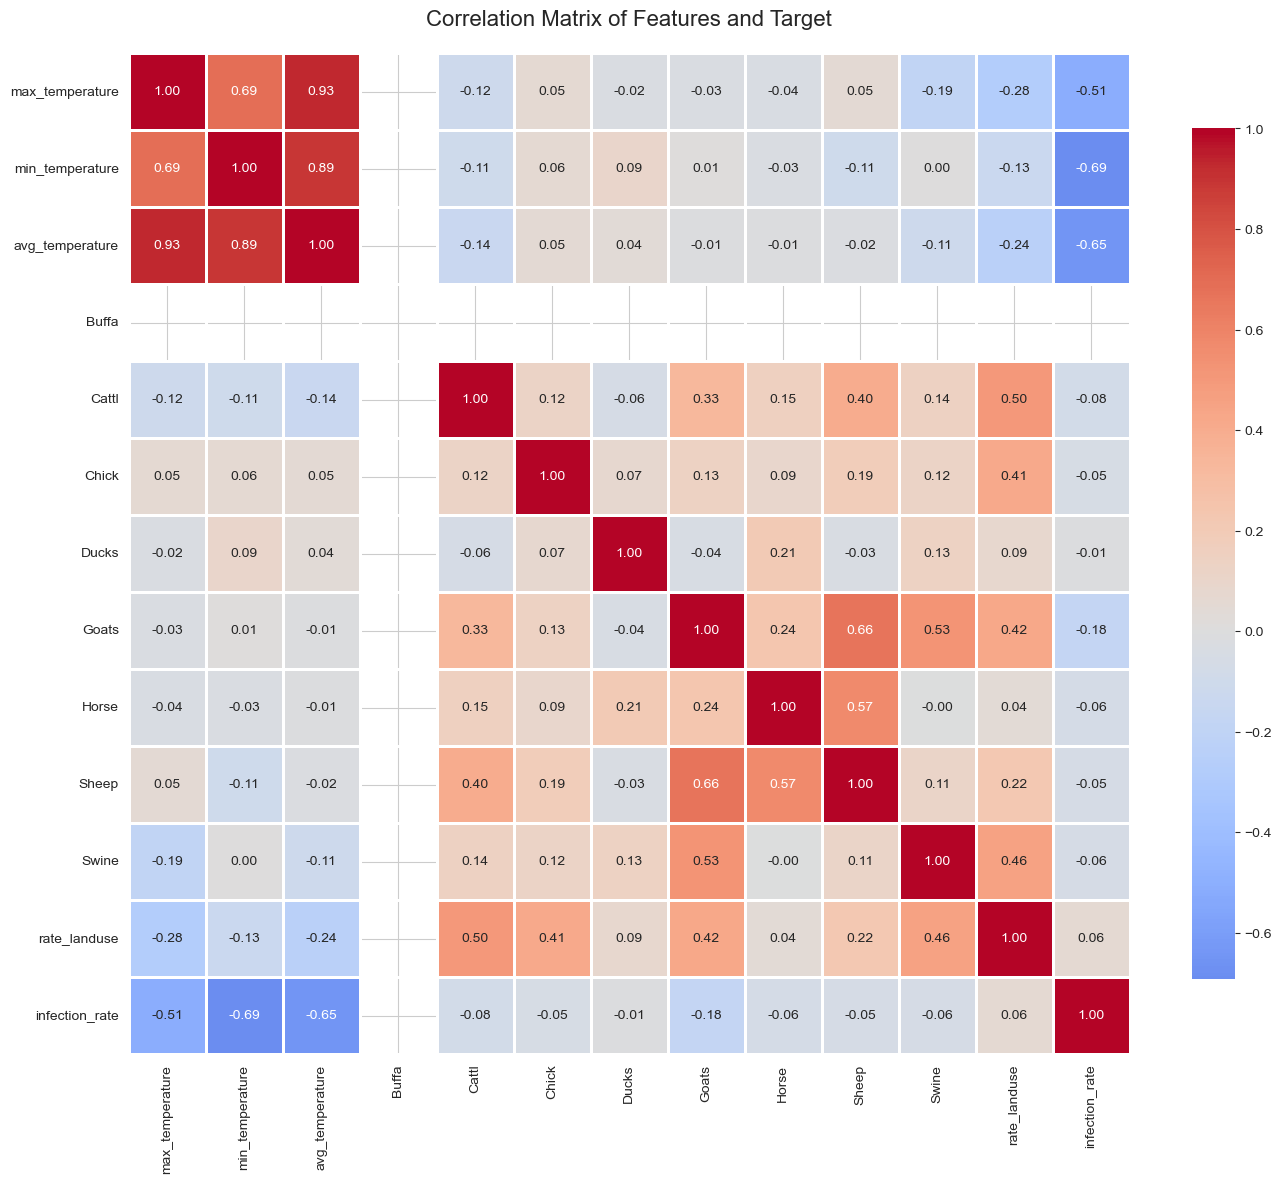

In [16]:
# 전체 상관관계 행렬
correlation_matrix = df[feature_cols + [target_col]].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Features and Target', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

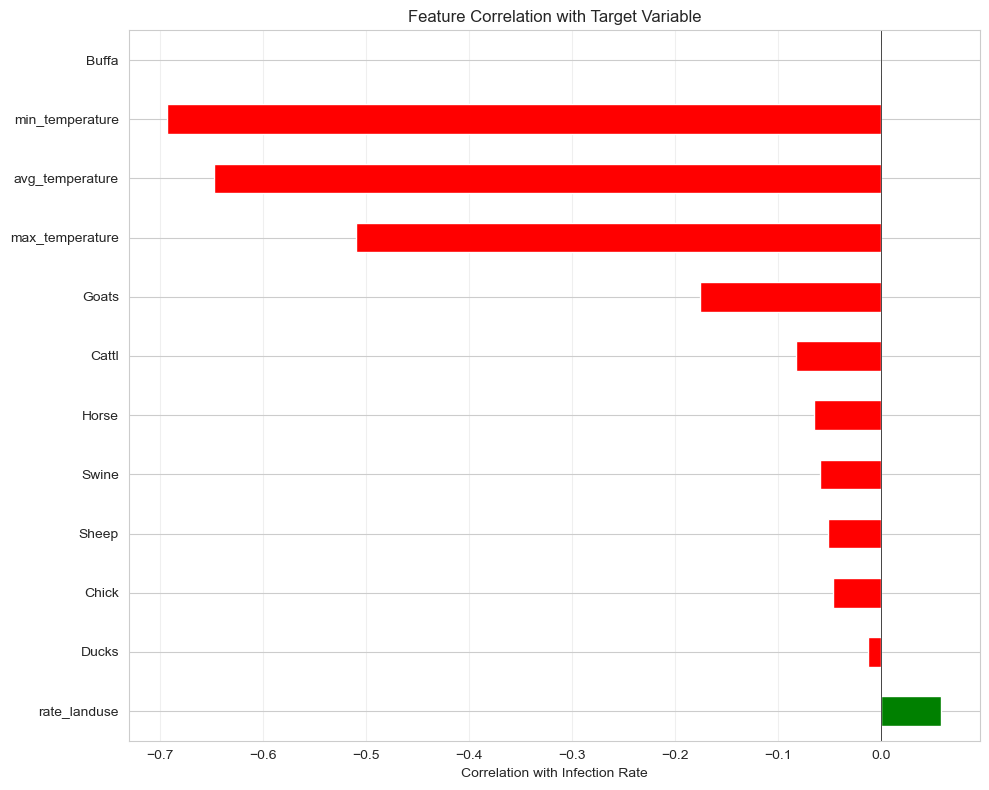


=== Target과의 상관계수 (절대값 기준 정렬) ===
min_temperature    0.692449
avg_temperature    0.647082
max_temperature    0.509773
Goats              0.175071
Cattl              0.082432
Horse              0.064763
Swine              0.059176
rate_landuse       0.058684
Sheep              0.051578
Chick              0.046243
Ducks              0.012047
Buffa                   NaN
Name: infection_rate, dtype: float64


In [17]:
# Target과의 상관관계
target_corr = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_corr])
plt.xlabel('Correlation with Infection Rate')
plt.title('Feature Correlation with Target Variable')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== Target과의 상관계수 (절대값 기준 정렬) ===")
print(target_corr.abs().sort_values(ascending=False))

## 10. Feature vs Target 관계 시각화

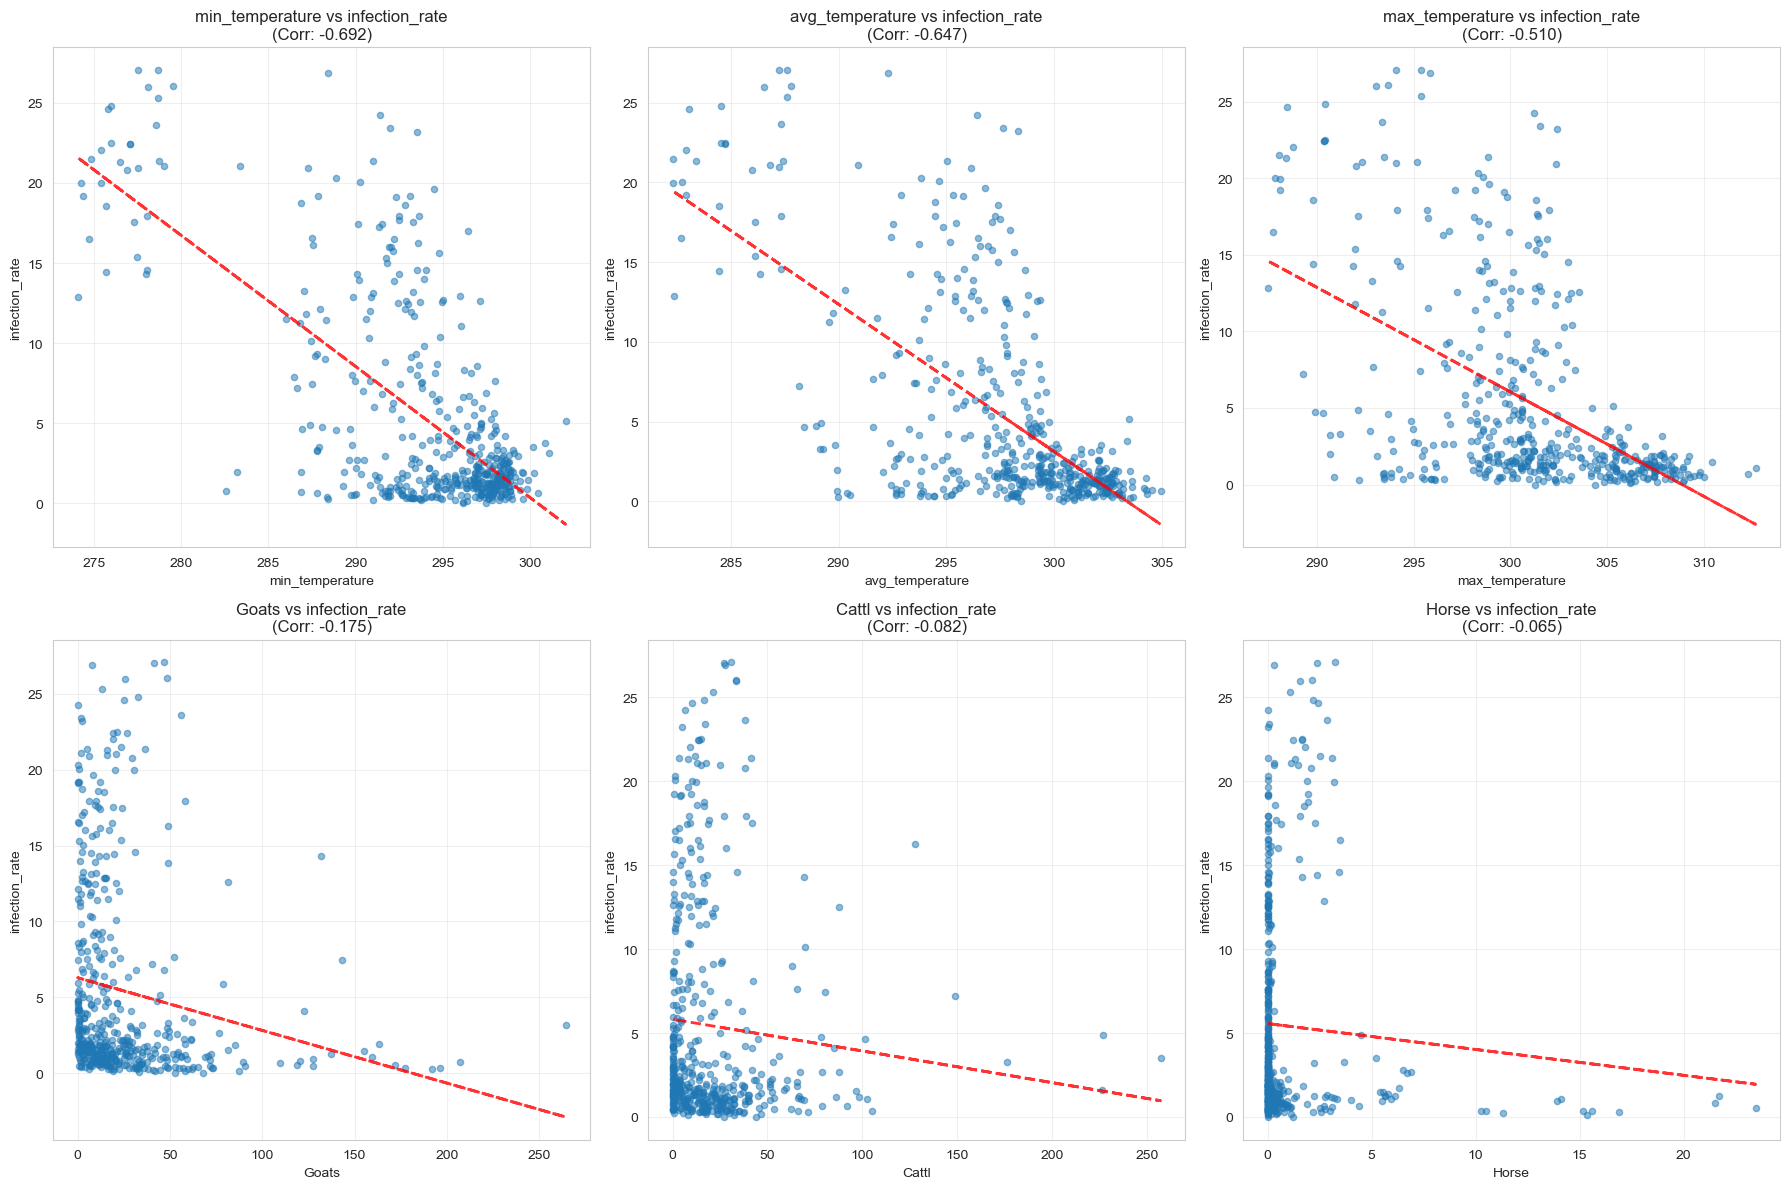

In [18]:
# 상관관계가 높은 상위 6개 feature와 target의 scatter plot
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df[target_col], alpha=0.5, s=20)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel(target_col)
    axes[idx].set_title(f'{feature} vs {target_col}\n(Corr: {target_corr[feature]:.3f})')
    
    # 회귀선 추가
    z = np.polyfit(df[feature], df[target_col], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()